In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
# Taking only 3 Column to demonstrate

df = pd.read_csv('../../DataBox/titanic_prepsd.csv',usecols=['Age','Fare','Survived'])

# Fill NA with mean # Cant do transformation with NA values
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [3]:
# Input - output  Columns

X = df.iloc[:,1:3]
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

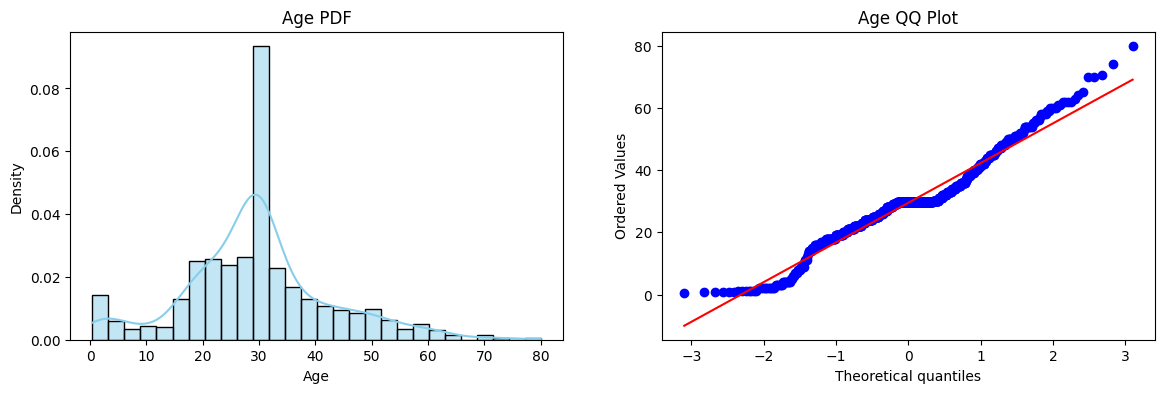

In [4]:
plt.figure(figsize=(14,4))

# Left Plot: Distribution (Histogram + PDF)
plt.subplot(121)

# Use histplot with kde=True and stat='density' to match the old distplot look
sns.histplot(X_train['Age'], kde=True, stat="density", color='skyblue')
plt.title('Age PDF')

# Right Plot: Q-Q Plot (Checking for Normality)
plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

# Observation -> Close to Normal Distribution

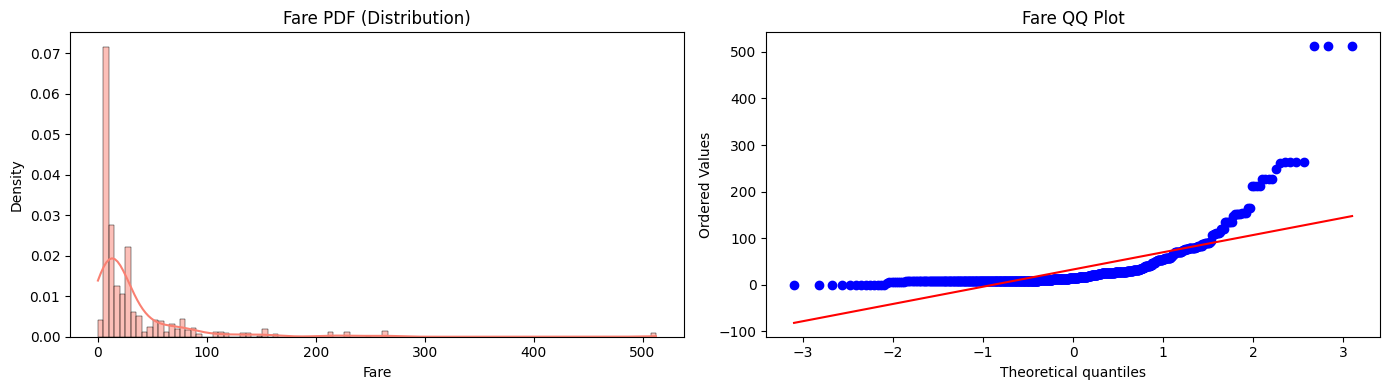

In [5]:
plt.figure(figsize=(14,4))

# 1. Left Plot: Fare Distribution (Histogram + KDE)
plt.subplot(121)
# Use histplot + kde=True to replace the deprecated distplot
sns.histplot(X_train['Fare'], kde=True, stat="density", color='salmon')
plt.title('Fare PDF (Distribution)')

# 2. Right Plot: Q-Q Plot (Checking for Normality)
plt.subplot(122)
# 'stats' refers to scipy.stats
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

# Observation -> Right Skewed  -> Log Transformation Will help

In [6]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [7]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


Apply on Both -> Age and Fare

In [8]:
# Custom or Built-in Function Transformer 
trf = FunctionTransformer(func=np.log1p) # np.logp -> Cant take 0   ** To Avoide **-> 1p (means p + 1) then take log

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


In [9]:
# Cross - Verification 

X_transformed = trf.fit_transform(X)  # X -> Input (Feature Matrix)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6610861423220973


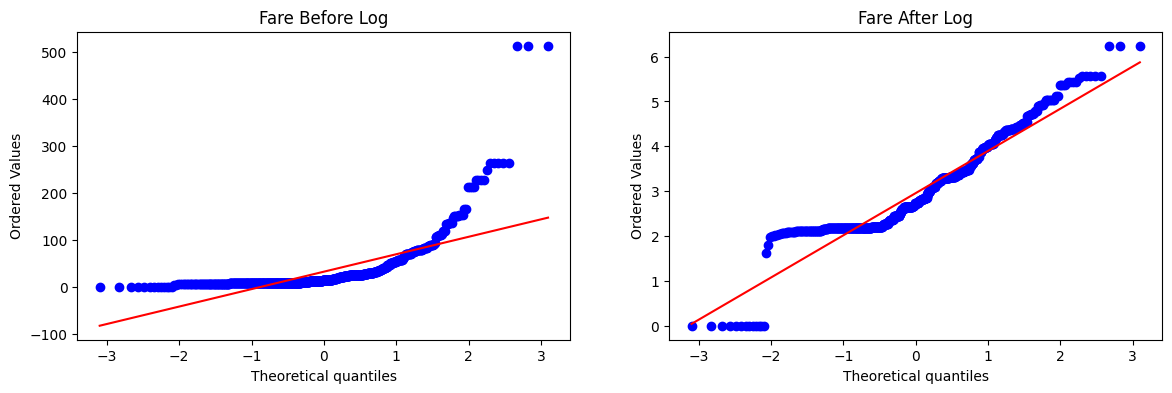

In [10]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

# Got Better After Log Transformation

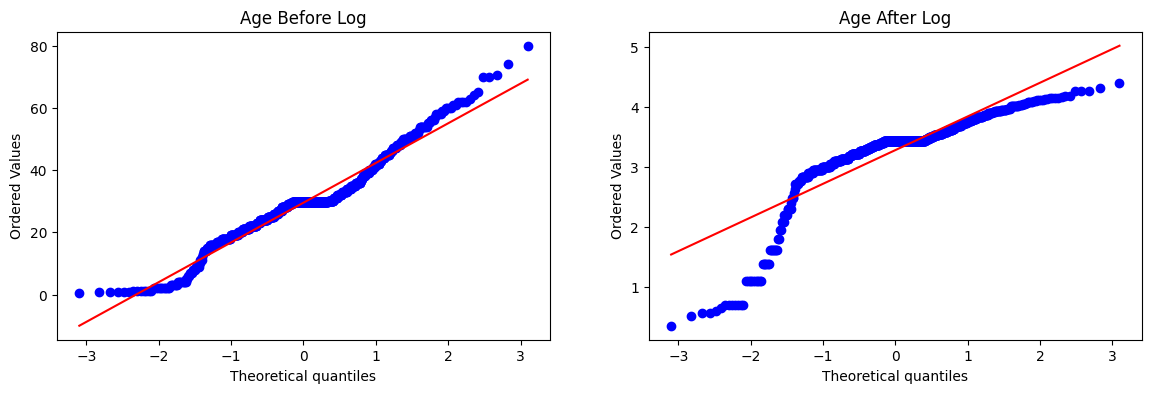

In [11]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

# We should not have applied log transform on this
# Before it was more accurately normally distributed

Only Fare this Time

In [12]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough') # Only Fare rest Pass

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.659217877094972


In [13]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6543570536828963


Apply Any Transformation

In [14]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('math',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    # Cross Verification Directly
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6589013732833957


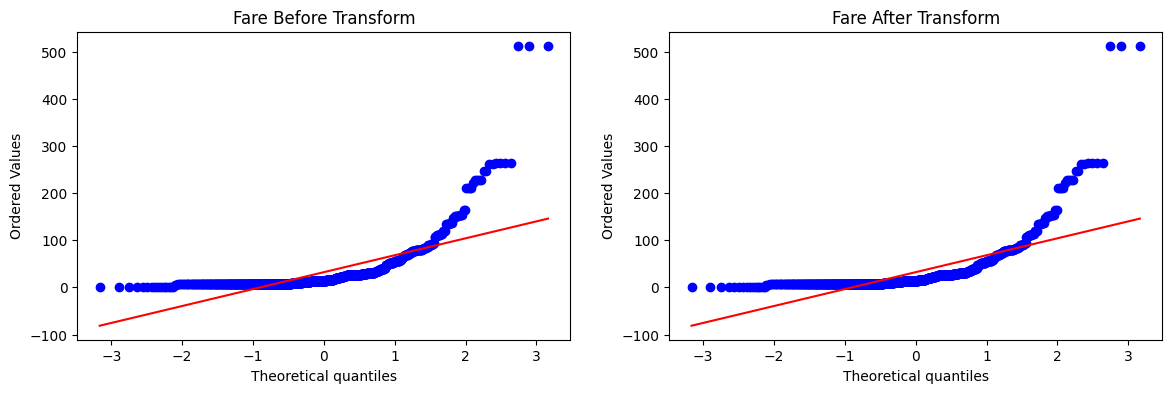

Accuracy 0.6431335830212235


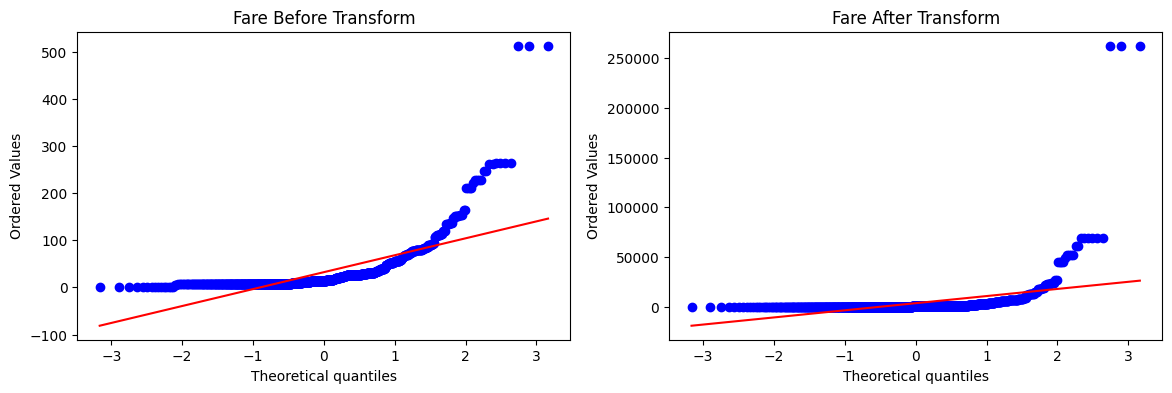

Accuracy 0.6262796504369538


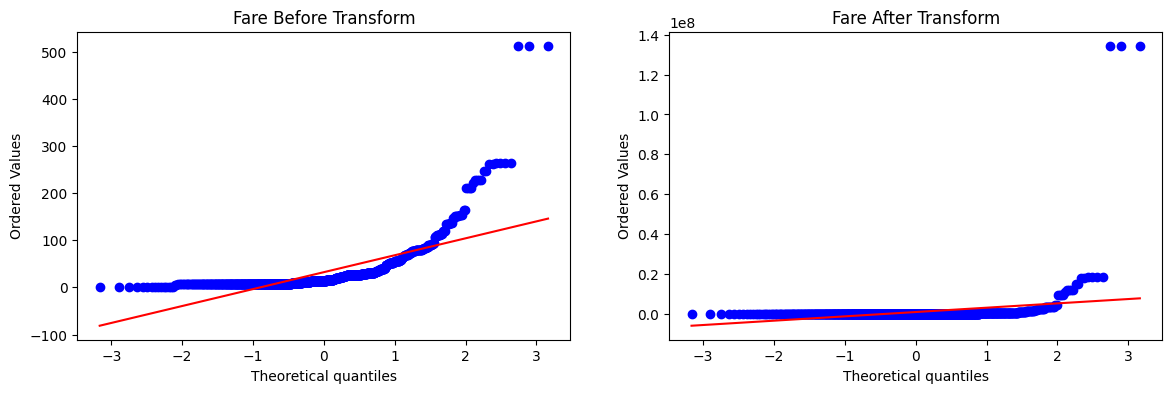

Accuracy 0.6589013732833957


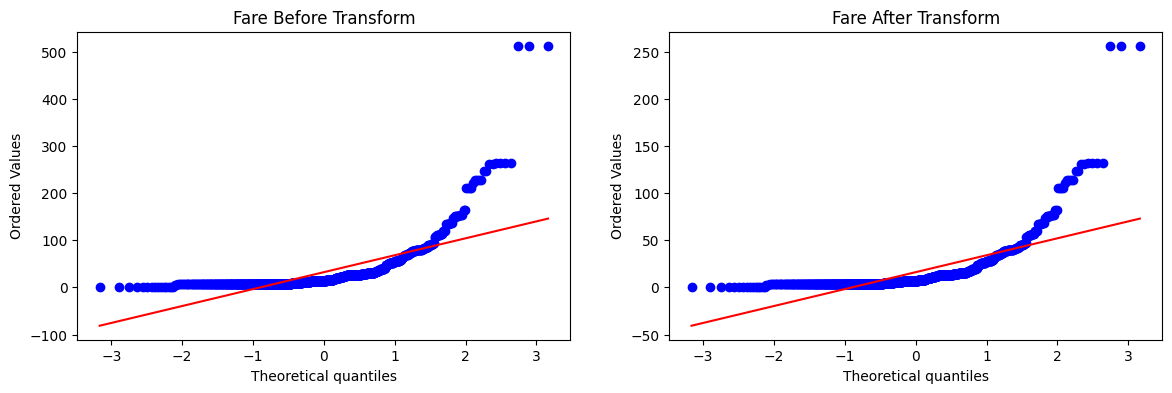

Accuracy 0.61729088639201


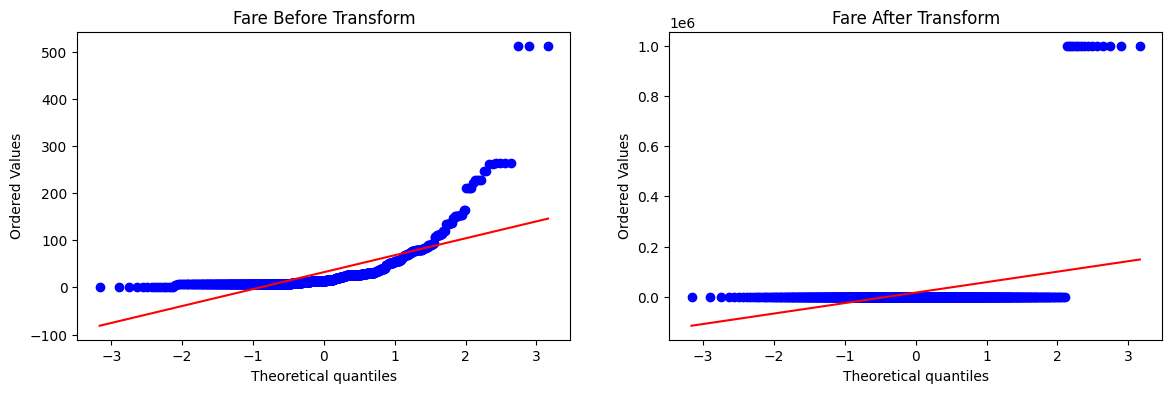

Accuracy 0.616167290886392


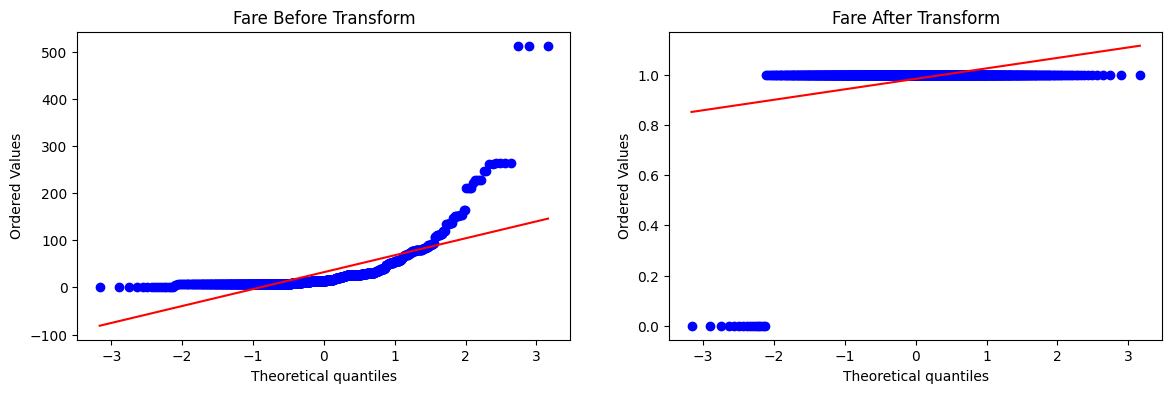

In [15]:
apply_transform(lambda x:x) # Without any trasnformation
apply_transform(lambda x:x**2) # Square
apply_transform(lambda x:x**3) # Cube
apply_transform(lambda x:x**1/2) # Sqrt
apply_transform(lambda x:1/(x+0.000001)) # Reciprocal # Denominator Should not be 0 -> Careful
apply_transform(np.sign) # Can and any custom Function